# Preparing Textual Data For Statistics and Machine Learning

## Compatibility with spaCy 3.x<div class="tocSkip"/>

We adjusted the this notebook to run with spaCy 3.2 and textacy 0.12.

## Setup<div class='tocSkip'/>

Set directory locations. If working on Google Colab: copy files and install required libraries.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# suppress warnings
import warnings;
warnings.filterwarnings('ignore');

# common imports
import pandas as pd
import numpy as np
import math
import re
import glob
import os
import sys
import json
import random
import pprint as pp
import textwrap
import sqlite3
import logging

import spacy
import nltk

from tqdm.auto import tqdm
# register `pandas.progress_apply` and `pandas.Series.map_apply` with `tqdm`
tqdm.pandas()

# pandas display options
# https://pandas.pydata.org/pandas-docs/stable/user_guide/options.html#available-options
pd.options.display.max_columns = 30 # default 20
pd.options.display.max_rows = 60 # default 60
pd.options.display.float_format = '{:.2f}'.format
# pd.options.display.precision = 2
pd.options.display.max_colwidth = 200 # default 50; -1 = all
# otherwise text between $ signs will be interpreted as formula and printed in italic
pd.set_option('display.html.use_mathjax', False)

# np.set_printoptions(edgeitems=3) # default 3

import matplotlib
from matplotlib import pyplot as plt

plot_params = {'figure.figsize': (8, 4),
               'axes.labelsize': 'large',
               'axes.titlesize': 'large',
               'xtick.labelsize': 'large',
               'ytick.labelsize':'large',
               'figure.dpi': 100}
# adjust matplotlib defaults
matplotlib.rcParams.update(plot_params)

import seaborn as sns
sns.set_style("darkgrid")


In [3]:
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/NATURAL_LANGUAGE_PROCESSING/session_2'
os.chdir(BASE_DIR)

In [4]:
# to print output of all statements and not just the last
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# otherwise text between $ signs will be interpreted as formula and printed in italic
pd.set_option('display.html.use_mathjax', False)

# path to import blueprints packages
sys.path.append(BASE_DIR + '/packages')

# A Data Preprocessing Pipeline


# Introducing the Data Set: Reddit Self Posts


## Loading Data into Pandas


In [5]:
import warnings
warnings.simplefilter("ignore")


In [6]:
posts_file = "./data/rspct_autos.tsv.gz" ### real location
posts_df = pd.read_csv(posts_file, sep='\t')
posts_df.info()
posts_df.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         20000 non-null  object
 1   subreddit  20000 non-null  object
 2   title      20000 non-null  object
 3   selftext   20000 non-null  object
dtypes: object(4)
memory usage: 625.1+ KB


,id,subreddit,title,selftext
0,8f73s7,Harley,No Club Colors,Funny story. I went to college in Las Vegas. This was before I knew anything about motorcycling whatsoever. Me and some college buddies would always go out on the strip to the dance clubs. We alwa...
1,5s0q8r,Mustang,Roush vs Shleby GT500,"I am trying to determine which is faster, and I've seen the dealership video with the two racing(Roush won 2/3). But I was wondering if it was just because of the bigass supercharger in the Roush...."
2,5z3405,Volkswagen,2001 Golf Wagon looking for some insight,Hello! <lb><lb>Trying to find some information on replacing a 2001 Golf Wagon starter (gas).... mine's gone out and going to the dealership is quite out of the range right now. Nor is it in the bi...


In [7]:
posts_df['subreddit'].value_counts()

Harley                1000
Mustang               1000
saab                  1000
MPSelectMiniOwners    1000
mazda3                1000
Hyundai               1000
BMW                   1000
Trucks                1000
Porsche               1000
subaru                1000
Wrangler              1000
mercedes_benz         1000
Audi                  1000
teslamotors           1000
Honda                 1000
Volvo                 1000
volt                  1000
Lexus                 1000
Volkswagen            1000
4Runner               1000
Name: subreddit, dtype: int64

In [8]:
subred_file = "./data/subreddit_info.csv.gz" ### real location
subred_df = pd.read_csv(subred_file).set_index(['subreddit'])
subred_df.info()
subred_df.head(3)

<class 'pandas.core.frame.DataFrame'>
Index: 3394 entries, whatsthatbook to Glitch_in_the_Matrix
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   category_1            3394 non-null   object
 1   category_2            3362 non-null   object
 2   category_3            536 non-null    object
 3   in_data               3394 non-null   bool  
 4   reason_for_exclusion  2381 non-null   object
dtypes: bool(1), object(4)
memory usage: 135.9+ KB


,category_1,category_2,category_3,in_data,reason_for_exclusion
subreddit,,,,,
whatsthatbook,advice/question,book,NaN,True,NaN
CasualConversation,advice/question,broad,NaN,False,too_broad
Clairvoyantreadings,advice/question,broad,NaN,False,too_broad


In [9]:
subred_df.index.value_counts()

whatsthatbook           1
linuxmasterrace         1
linuxquestions          1
openSUSE                1
unixporn                1
                       ..
StLouis                 1
Tucson                  1
TwinCities              1
UMF                     1
Glitch_in_the_Matrix    1
Name: subreddit, Length: 3394, dtype: int64

The following line of code creates a set of unique subreddit names from the `'subreddit'` column in the `posts_df` DataFrame. This is achieved by passing the column to the `set()` function, which removes any duplicate entries.

Then, it calculates the intersection of this set with the index of the `subred_df` DataFrame. The `.intersection()` method is used to find common elements between two sets.

The result is a set of subreddit names that are present in both the `posts_df` `'subreddit'` column and as indices in `subred_df`. This list includes names like 'Audi', 'BMW', 'Honda', and more, suggesting that these are subreddit names related to automotive brands or topics.

In [ ]:
set(posts_df['subreddit']).intersection(subred_df.index)

{'4Runner',
 'Audi',
 'BMW',
 'Harley',
 'Honda',
 'Hyundai',
 'Lexus',
 'MPSelectMiniOwners',
 'Mustang',
 'Porsche',
 'Trucks',
 'Volkswagen',
 'Volvo',
 'Wrangler',
 'mazda3',
 'mercedes_benz',
 'saab',
 'subaru',
 'teslamotors',
 'volt'}

The following code performs a join operation between two dataframes and then gets the length of the resulting dataframe:

`df = posts_df.join(subred_df, on='subreddit')`: This line joins the `posts_df` dataframe with the `subred_df` dataframe using the `'subreddit'` column as the key. The default join is a left join, which means all entries in `posts_df` will be kept, and matching entries from `subred_df` will be added to it.

The joined dataframe contains 20,000 rows.

In [11]:
df = posts_df.join(subred_df, on='subreddit')
len(df) ###

20000

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    20000 non-null  object
 1   subreddit             20000 non-null  object
 2   title                 20000 non-null  object
 3   selftext              20000 non-null  object
 4   category_1            20000 non-null  object
 5   category_2            20000 non-null  object
 6   category_3            0 non-null      object
 7   in_data               20000 non-null  bool  
 8   reason_for_exclusion  0 non-null      object
dtypes: bool(1), object(8)
memory usage: 1.2+ MB


In [13]:
df.head(3)

,id,subreddit,title,selftext,category_1,category_2,category_3,in_data,reason_for_exclusion
0,8f73s7,Harley,No Club Colors,Funny story. I went to college in Las Vegas. This was before I knew anything about motorcycling whatsoever. Me and some college buddies would always go out on the strip to the dance clubs. We alwa...,autos,harley davidson,NaN,True,NaN
1,5s0q8r,Mustang,Roush vs Shleby GT500,"I am trying to determine which is faster, and I've seen the dealership video with the two racing(Roush won 2/3). But I was wondering if it was just because of the bigass supercharger in the Roush....",autos,ford,NaN,True,NaN
2,5z3405,Volkswagen,2001 Golf Wagon looking for some insight,Hello! <lb><lb>Trying to find some information on replacing a 2001 Golf Wagon starter (gas).... mine's gone out and going to the dealership is quite out of the range right now. Nor is it in the bi...,autos,VW,NaN,True,NaN


In [14]:
df.isnull().sum()

id                          0
subreddit                   0
title                       0
selftext                    0
category_1                  0
category_2                  0
category_3              20000
in_data                     0
reason_for_exclusion    20000
dtype: int64

## Standardizing Attribute Names


The following code is for standardizing column names in a DataFrame.

This line prints out the current column names in the dataframe `df`.

In [15]:
print(df.columns)

Index(['id', 'subreddit', 'title', 'selftext', 'category_1', 'category_2',
       'category_3', 'in_data', 'reason_for_exclusion'],
      dtype='object')


The dictionary `column_mapping` is created to map existing column names to new standardized names. For example, `'selftext'` will be renamed to `'text'`, `'category_1'` to `'category'`, and `'category_2'` to `'subcategory'`. Some columns are mapped to `None`, indicating that they will be dropped as they contain no data or are not needed.

The list comprehension creates a list `columns` containing column names that are not mapped to `None`, i.e., the columns that will be kept.

`df = df[columns].rename(columns=column_mapping)`: This line selects only the columns that are to be kept and renames them according to the `column_mapping`. The columns mapped to `None` are implicitly dropped as they are not included in the columns list.

In [16]:
column_mapping = {
    'id': 'id',
    'subreddit': 'subreddit',
    'title': 'title',
    'selftext': 'text',
    'category_1': 'category',
    'category_2': 'subcategory',
    'category_3': None, # no data
    'in_data': None, # not needed
    'reason_for_exclusion': None # not needed
}

# define remaining columns
columns = [c for c in column_mapping.keys() if column_mapping[c] != None]

# select and rename those columns
df = df[columns].rename(columns=column_mapping)

In [17]:
columns

['id', 'subreddit', 'title', 'selftext', 'category_1', 'category_2']

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           20000 non-null  object
 1   subreddit    20000 non-null  object
 2   title        20000 non-null  object
 3   text         20000 non-null  object
 4   category     20000 non-null  object
 5   subcategory  20000 non-null  object
dtypes: object(6)
memory usage: 937.6+ KB


In [19]:
df.nunique()

id             20000
subreddit         20
title          19957
text           20000
category           1
subcategory       20
dtype: int64

In [20]:
df.head(3)

,id,subreddit,title,text,category,subcategory
0,8f73s7,Harley,No Club Colors,Funny story. I went to college in Las Vegas. This was before I knew anything about motorcycling whatsoever. Me and some college buddies would always go out on the strip to the dance clubs. We alwa...,autos,harley davidson
1,5s0q8r,Mustang,Roush vs Shleby GT500,"I am trying to determine which is faster, and I've seen the dealership video with the two racing(Roush won 2/3). But I was wondering if it was just because of the bigass supercharger in the Roush....",autos,ford
2,5z3405,Volkswagen,2001 Golf Wagon looking for some insight,Hello! <lb><lb>Trying to find some information on replacing a 2001 Golf Wagon starter (gas).... mine's gone out and going to the dealership is quite out of the range right now. Nor is it in the bi...,autos,VW


The following line of code counts the number of occurrences of each unique value in the `'category'` column of the dataframe `df`. The output indicates that the value `'autos'` occurs 20,000 times in the `'category'` column. That is, the `category` column has only one unique value (`'autos'`) across all 20,000 observations.

In [21]:
df['category'].value_counts()

autos    20000
Name: category, dtype: int64

The following line of code removes the `'category'` column from the dataframe `df`. The `drop()` method is used to delete the specified column, and the result is assigned back to `df`, effectively updating the dataframe to no longer include the `'category'` column. A column with only a single value doesn't provide any useful information for analysis or modeling, since it doesn't contribute to any variance in the data. Dropping such a column can simplify the dataset and potentially improve the performance of any data analysis or predictive modeling done later on.

In [22]:
df = df.drop(columns=['category'])

In [23]:
len(df)

20000

`pd.options.display.max_colwidth = None`: This line sets the maximum column width for the display of pandas DataFrame columns to `None`, meaning it will display the entire content of each column without truncation.

`df.sample(1, random_state=7).T`: This line randomly samples one row from the df DataFrame (with a set random state for reproducibility) and transposes it with `.T` so that the columns are displayed as rows, making it easier to read all the data in the row.

`pd.options.display.max_colwidth = 200`: This line resets the maximum column width for display back to 200 characters, truncating any content in each column beyond this limit when displayed.

In [24]:
pd.options.display.max_colwidth = None ###
df.sample(1, random_state=7).T
pd.options.display.max_colwidth = 200 ###

,14356
id,7jc2k4
subreddit,volt
title,Dashcam for 2017 volt
text,Hello.<lb>I'm looking into getting a dashcam. <lb>Does anyone have any recommendations? <lb><lb>I'm generally looking for a rechargeable one so that I don't have to route wires down to the cigarette lighter. <lb>Unless there are instructions on how to wire it properly without wires showing. <lb><lb><lb>Thanks!
subcategory,chevrolet


## Saving and Loading a Data Frame


This line saves the DataFrame `df` to a pickle file. Pickling is a way to serialize and save a Python object to a file, which can then be loaded back at a later time.

In [25]:
df.to_pickle("./data/reddit_dataframe.pkl")

The next block imports the `sqlite3` library, which allows interaction with SQLite databases.

`db_name = "./data/reddit-selfposts.db"`: Sets the database file path.

`con = sqlite3.connect(db_name)`: Creates a connection to the SQLite database file.

`df.to_sql("posts", con, index=False, if_exists="replace")`: Saves the DataFrame `df` to the SQLite database as a table named `"posts"`. If the table already exists, it is replaced. The `index=False` parameter means that the DataFrame's index will not be saved as a separate column in the database.

`con.close()`: Closes the connection to the database.

In [26]:
import sqlite3

db_name = "./data/reddit-selfposts.db"
con = sqlite3.connect(db_name)
df.to_sql("posts", con, index=False, if_exists="replace")
con.close()

20000

A new connection to the same SQLite database is made.

`df = pd.read_sql("select * from posts", con)`: Loads the "posts" table from the SQLite database into a new DataFrame df.

Closes the database connection again.

In [27]:
con = sqlite3.connect(db_name)
df = pd.read_sql("select * from posts", con)
con.close()

`len(df)`: Checks the number of rows in the loaded DataFrame, confirming that it still has 20,000 rows, matching the number before it was saved to the database.

In [28]:
len(df)

20000

# Cleaning Text Data


In [29]:
text = """
After viewing the [PINKIEPOOL Trailer](https://www.youtu.be/watch?v=ieHRoHUg)
it got me thinking about the best match ups.
<lb>Here's my take:<lb><lb>[](/sp)[](/ppseesyou) Deadpool<lb>[](/sp)[](/ajsly)
Captain America<lb>"""

In [30]:
print(text)


After viewing the [PINKIEPOOL Trailer](https://www.youtu.be/watch?v=ieHRoHUg)
it got me thinking about the best match ups.
<lb>Here's my take:<lb><lb>[](/sp)[](/ppseesyou) Deadpool<lb>[](/sp)[](/ajsly)
Captain America<lb>


## Identify Noise with Regular Expressions


The `re` library is imported for working with regular expressions.

A regular expression pattern `RE_SUSPICIOUS` is compiled to match HTML tags and other non-alphanumeric characters which are considered 'noise' in the text data.

The function `impurity` is defined to calculate the proportion of 'noise' characters in a given text by using the compiled regular expression to find all matches and then dividing the number of matches by the total length of the text.

The function is tested on the sample text, and the impurity proportion is printed, which is approximately 0.0909, meaning around 9% of the text consists of 'noise' characters.

In [31]:
import re

RE_SUSPICIOUS = re.compile(r'[&#<>{}\[\]\\]')

def impurity(text, min_len=10):
    """returns the share of suspicious characters in a text"""
    if text == None or len(text) < min_len:
        return 0
    else:
        return len(RE_SUSPICIOUS.findall(text))/len(text)

print(impurity(text))

0.09009009009009009


The maximum column width for pandas display is set to 100 to ensure that the DataFrame display is truncated for easier viewing.

The `impurity` function is applied to the `'text'` column of the DataFrame `df` to calculate the impurity for each row, and the result is stored in a new column `'impurity'`.

The DataFrame is sorted by the `'impurity'` column in descending order, and the top 3 records with the highest impurity scores are displayed. This gives an idea of the text entries that have the most noise and might require cleaning.

Finally, the maximum column width setting is reset to 200 characters.

In [32]:
pd.options.display.max_colwidth = 100 ###
# add new column to data frame
df['impurity'] = df['text'].progress_apply(impurity, min_len=10)

# get the top 3 records
df[['text', 'impurity']].sort_values(by='impurity', ascending=False).head(3)
pd.options.display.max_colwidth = 200 ###

  0%|          | 0/20000 [00:00<?, ?it/s]

,text,impurity
19682,Looking at buying a 335i with 39k miles and 11 months left on the CPO warranty. I asked the deal...,0.21
12357,I'm looking to lease an a4 premium plus automatic with the nav package.<lb><lb>Vehicle Price:<ta...,0.17
2730,Breakdown below:<lb><lb>Elantra GT<lb><lb>2.0L 4-cylinder<lb><lb>6-speed Manual Transmission<lb>...,0.14


In [33]:
import locale
def getpreferredencoding(do_setlocale = True):
    return "UTF-8"
locale.getpreferredencoding = getpreferredencoding

In [34]:
try:
  import textacy
except:
  !pip install textacy
  import textacy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.7/210.7 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 17.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.4/320.4 kB 34.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 54.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 80.5 MB/s eta 0:00:00


The following code is using a custom function `count_words` from a module `exploration` which is part of a package `packages`. The function is used to count the frequency of each unique token in the `'text'` column of the DataFrame `df`.

Here's what the code is doing:

*   It imports the `count_words` function from the `exploration` module.
*   It calls `count_words` with the DataFrame `df`, specifying which column to count words from (`column='text'`), and provides a custom preprocessing function as a `lambda` function.
*   The `lambda` function uses the regular expression `re.findall(r'<\w+/*>', t)` to find all occurrences of tokens that look like HTML tags (e.g., \<br\>, \<tab\>).
*   The `count_words` function then presumably counts the occurrences of each unique token (in this case, HTML tags) found by the regular expression.
*   The output shows the two most frequent tokens: \<lb\> appears 100,729 times, and \<tab\> appears 642 times.

The `count_words` function is most likely intended to be used for exploring the text data, identifying the frequency of words or tokens, which is a common step in text analysis and natural language processing. In this context, it seems to be identifying HTML or similar markup tags, which might need to be cleaned from the text.

In [35]:
from packages.exploration import count_words
count_words(df, column='text', preprocess=lambda t: re.findall(r'<[\w/]*>', t))

  0%|          | 0/20000 [00:00<?, ?it/s]

,freq
token,
<lb>,100729
<tab>,642


## Noise Removal with Regular Expressions


By comparing the impurity scores before and after cleaning, one can assess the effectiveness of the cleaning process. The `clean` function is a critical step in preprocessing text data for natural language processing applications, as it standardizes the text by removing extraneous information that could interfere with analyses or model training.

The `html` module is imported to unescape HTML entities in the text.

A function `clean(text)` is defined, which sequentially:

*   Unescapes HTML entities in the text.
*   Uses various regular expression substitutions (`re.sub`) to remove HTML tags, markdown, and other non-alphanumeric characters.
*   Converts the text to lowercase and strips whitespace from both ends of the string.

In [36]:
import html

def clean(text):
    text = html.unescape(text)
    text = re.sub(r'<[^<>]*>', ' ', text)
    text = re.sub(r'\[([^\[\]]*)\]\([^\(\)]*\)', r'\1', text)
    text = re.sub(r'\[[^\[\]]*\]', ' ', text)
    text = re.sub(r'(?:^|\s)[&#<>{}\[\]+|\\:-]{1,}(?:\s|$)', ' ', text)
    text = re.sub(r'(?:^|\s)[\-=\+]{2,}(?:\s|$)', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.lower().strip()

In [37]:
print(text)


After viewing the [PINKIEPOOL Trailer](https://www.youtu.be/watch?v=ieHRoHUg)
it got me thinking about the best match ups.
<lb>Here's my take:<lb><lb>[](/sp)[](/ppseesyou) Deadpool<lb>[](/sp)[](/ajsly)
Captain America<lb>


The `clean(text)` function is applied to a sample text, the cleaned text is printed out, and the impurity score is calculated using the impurity function (from previous snippets).

The impurity score is now 0.0, indicating that the noise has been successfully removed from the sample text.

In [38]:
clean_text = clean(text)
print(clean_text)
print("Impurity:", impurity(clean_text))

after viewing the pinkiepool trailer it got me thinking about the best match ups. here's my take: deadpool captain america
Impurity: 0.0


The `clean` function is then applied to the entire `'text'` column of the DataFrame `df` using the `progress_map` function, which provides a progress bar for the operation.

A new `'impurity'` score is calculated for the cleaned text using the `impurity` function, but with a higher minimum length threshold (`min_len=20`).

In [39]:
df['clean_text'] = df['text'].progress_map(clean)
df['impurity']   = df['clean_text'].apply(impurity, min_len=20)

  0%|          | 0/20000 [00:00<?, ?it/s]

The DataFrame `df` is sorted by the new `'impurity'` column in descending order, and the top 3 entries are displayed to review the texts with the highest remaining impurity after cleaning.

In [40]:
df[['clean_text', 'impurity']].sort_values(by='impurity', ascending=False) \
                              .head(3)

,clean_text,impurity
14058,"mustang 2018, 2019, or 2020? must haves!! 1. have a credit score of 780\+ for the best low interest rates! 2. join a credit union to finance the vehicle! 3. or find a lender to finance the vehicle...",0.03
18934,"at the dealership, they offered an option for foot-well illumination, but i cannot find any reference to this online. has anyone gotten it? how does it look? anyone have pictures. not sure if this...",0.03
16505,"i am looking at four caymans, all are in a similar price range. the major differences are the miles, the years, and one isn’t a s. https://www.cargurus.com/cars/inventorylisting/viewdetailsfilterv...",0.02


## Character Normalization with textacy


The purpose of these snippets is to demonstrate how text preprocessing functions from the `textacy` library can be used for normalizing text, which is a common requirement in natural language processing to ensure consistency in the data.

A sample `text` containing special characters, such as the é in café and the hyphenated word "Saint-Raphaël", is defined.

The script prints the original text and then the text after applying the `clean` function.

In [41]:
text = "The café “Saint-Raphaël” is loca-\nted on Côte dʼAzur."

In [42]:
print(f"original text: {text}")
print(f"text after clean function: {clean(text)}")

original text: The café “Saint-Raphaël” is loca-
ted on Côte dʼAzur.
text after clean function: the café “saint-raphaël” is loca- ted on côte dʼazur.


The `textacy` library is imported, along with its preprocessing module `textacy.preprocessing as tprep`.

A conditional check is performed on the version of `textacy`. If it's below 0.11, a certain set of functions is used; otherwise, an adjusted set is used for version 0.11 or above.

The `normalize` function is defined, which applies several `textacy` preprocessing functions to the input text:
*   `normalize_hyphenated_words`: Normalizes hyphenated words.
*   `normalize_quotation_marks`: Normalizes different types of quotation marks to a standard form.
*   `normalize_unicode`: Normalizes unicode characters into a canonical form.
*   `remove_accents`: Removes accents from characters.

In [43]:
import textacy
import textacy.preprocessing as tprep

if textacy.__version__ < '0.11':
    # as in book
    def normalize(text):
        text = tprep.normalize_hyphenated_words(text)
        text = tprep.normalize_quotation_marks(text)
        text = tprep.normalize_unicode(text)
        text = tprep.remove_accents(text)
        return text

else:
    # adjusted to textacy 0.11
    def normalize(text):
        text = tprep.normalize.hyphenated_words(text)
        text = tprep.normalize.quotation_marks(text)
        text = tprep.normalize.unicode(text)
        text = tprep.remove.accents(text)
        return text

After defining the `normalize` function, it's applied to the sample text and the result is printed out. The processed text normalizes the unicode characters and removes special character formatting such as accents.

In [44]:
print(normalize(text))

The cafe "Saint-Raphael" is located on Cote d'Azur.


## Pattern-based Data Masking with textacy


These steps demonstrate the typical workflow for cleaning textual data, which includes normalizing text, removing or masking unwanted patterns (like URLs), and preparing the data for storage or further analysis. The use of pattern-based data masking is common when dealing with URLs, email addresses, phone numbers, or other identifiable information that should be anonymized or standardized across the dataset.

The `RE_URL` regular expression from `textacy` is imported, which is designed to match URLs in text.

The `count_words` function is called on the `df` DataFrame's `'clean_text'` column to count occurrences of URLs using the `RE_URL.findall` method. The top 3 most frequent URLs are displayed.

In [45]:
from textacy.preprocessing.resources import RE_URL

count_words(df, column='clean_text', preprocess=RE_URL.findall).head(3)

  0%|          | 0/20000 [00:00<?, ?it/s]

,freq
token,
www.getlowered.com,3
http://www.ecolamautomotive.com/#!2/kv7fq,2
https://www.reddit.com/r/jeep/comments/4ux232/just_ordered_an_android_head_unit_joying_jeep/,2


A conditional check based on the `textacy` version determines which `replace_urls` function to use for URL replacement.

A sample text containing a URL is processed with the `replace_urls` function, replacing URLs with a placeholder string `"URL"`.

In [46]:
if textacy.__version__ < '0.11':
    # as in book
    replace_urls = textacy.preprocessing.replace_urls
else:
    replace_urls = textacy.preprocessing.replace.urls

text = "Check out https://spacy.io/usage/spacy-101"

# using default substitution _URL_
print(replace_urls(text))

Check out _URL_


The `replace_urls` function is applied to the `'clean_text'` column of `df` using `progress_map`, which shows progress for long operations.

The `normalize` function is applied afterward in the same manner.

In [47]:
df['clean_text'] = df['clean_text'].progress_map(replace_urls)
df['clean_text'] = df['clean_text'].progress_map(normalize)

  0%|          | 0/20000 [00:00<?, ?it/s]

  0%|          | 0/20000 [00:00<?, ?it/s]

The `DataFrame` is then processed to:
*   Rename `'clean_text'` to `'text'`.
*   Drop the `'impurity'` column.

The modified DataFrame is saved to an SQLite database in a table named `"posts_cleaned"`.

In [48]:
df.rename(columns={'text': 'raw_text', 'clean_text': 'text'}, inplace=True)
df.drop(columns=['impurity'], inplace=True)

con = sqlite3.connect(db_name)
df.to_sql("posts_cleaned", con, index=False, if_exists="replace")
con.close()

20000

The `.iloc` method is used to view specific rows of the DataFrame, showing the text before and after cleaning. The processed text no longer contains URLs, which have been replaced with the "URL" placeholder.

In [49]:
df.iloc[[2,3],]

,id,subreddit,title,raw_text,subcategory,text
2,5z3405,Volkswagen,2001 Golf Wagon looking for some insight,Hello! <lb><lb>Trying to find some information on replacing a 2001 Golf Wagon starter (gas).... mine's gone out and going to the dealership is quite out of the range right now. Nor is it in the bi...,VW,hello! trying to find some information on replacing a 2001 golf wagon starter (gas).... mine's gone out and going to the dealership is quite out of the range right now. nor is it in the biggest of...
3,7df18v,Lexus,IS 250 Coolant Flush/Change,https://www.cars.com/articles/how-often-should-i-change-engine-coolant-1420680853669/<lb><lb>I have a IS 250 AWD from 2006. About 73K miles on it. I've never touched the engine radiator coolant an...,lexus,_URL_ i have a is 250 awd from 2006. about 73k miles on it. i've never touched the engine radiator coolant and can't find anything on when to change this in the book. it just says 'long life 100k ...


# Tokenization


Tokenization is the task of splitting a text into meaningful elements called tokens.

A string `text` is defined containing a date, a username, some natural language, an email address, and emojis.

In [50]:
text = """
2019-08-10 23:32: @pete/@louis - I don't have a well-designed
solution for today's problem. The code of module AC68 should be -1.
Have to think a bit... #goodnight ;-) 😩😬"""

## Tokenization with Regular Expressions


The string is then tokenized using a regular expression `re.findall(r'\w+', text)` which matches sequences of alphanumeric characters (words). The tokens are printed out separated by pipes (`|`).

In [51]:
tokens = re.findall(r'\w\w+', text)
print(*tokens, sep='|')

2019|08|10|23|32|pete|louis|don|have|well|designed|solution|for|today|problem|The|code|of|module|AC68|should|be|Have|to|think|bit|goodnight


In [52]:
tokens = re.findall(r'\w\w+', text)
print(tokens)

['2019', '08', '10', '23', '32', 'pete', 'louis', 'don', 'have', 'well', 'designed', 'solution', 'for', 'today', 'problem', 'The', 'code', 'of', 'module', 'AC68', 'should', 'be', 'Have', 'to', 'think', 'bit', 'goodnight']


A more sophisticated regular expression (`RE_TOKEN`) is compiled, which is designed to match:
*   Words, hashtags, and email addresses.
*   A coarse pattern for basic text emojis.
*   A coarse code range for Unicode emojis.

A function `tokenize` is defined to return all matches of `RE_TOKEN` in the input text.

This function is then used on the `text` string, and the resulting tokens are printed.

The output shows that this method is more effective at capturing elements like dates, email addresses, and punctuation, which were not captured using the simpler `\w+` pattern.

In [53]:
RE_TOKEN = re.compile(r"""
               ( [#]?[@\w'’\.\-\:]*\w     # words, hash tags and email adresses
               | [:;<]\-?[\)\(3]          # coarse pattern for basic text emojis
               | [\U0001F100-\U0001FFFF]  # coarse code range for unicode emojis
               )
               """, re.VERBOSE)

def tokenize(text):
    return RE_TOKEN.findall(text)

tokens = tokenize(text)
print(tokens)

['2019-08-10', '23:32', '@pete', '@louis', 'I', "don't", 'have', 'a', 'well-designed', 'solution', 'for', "today's", 'problem', 'The', 'code', 'of', 'module', 'AC68', 'should', 'be', '-1', 'Have', 'to', 'think', 'a', 'bit', '#goodnight', ';-)', '😩', '😬']


The second approach is a more comprehensive tokenization method, capturing a wider range of tokens found in typical text data, which can include various symbols and punctuation, not just alphanumeric characters. This is particularly useful in NLP tasks where such elements may carry significant meaning, such as in sentiment analysis or topic modeling.

## Tokenization with NLTK


Tokenization is a fundamental step in many NLP tasks, as it transforms text into an array of tokens that can be further processed, analyzed, or used as input for machine learning models. Different tokenizers serve different purposes and are suited to different types of text, so choosing the right one is crucial for effective text analysis.

The `punkt` tokenizer model is downloaded using `nltk.download('punkt')`. This model is a pre-trained tokenizer for English.

`nltk.tokenize.word_tokenize` is used to tokenize a text into individual words and punctuation.

The tokens are printed, showing how `word_tokenize` separates punctuation and words.

In [54]:
nltk.download('punkt') ###
tokens = nltk.tokenize.word_tokenize(text)
print()
print(tokens)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True


['2019-08-10', '23:32', ':', '@', 'pete/', '@', 'louis', '-', 'I', 'do', "n't", 'have', 'a', 'well-designed', 'solution', 'for', 'today', "'s", 'problem', '.', 'The', 'code', 'of', 'module', 'AC68', 'should', 'be', '-1', '.', 'Have', 'to', 'think', 'a', 'bit', '...', '#', 'goodnight', ';', '-', ')', '😩😬']


A regular expression tokenizer `nltk.tokenize.RegexpTokenizer` is initialized with a pattern from `RE_TOKEN.pattern`. This is a custom pattern tailored to capture words, hashtags, email addresses, emojis, etc.

The tokenizer is used to tokenize the text, and the result is printed, showing how this method captures elements based on the specified pattern.

In [55]:
# Not in book: Regex Tokenizer
tokenizer = nltk.tokenize.RegexpTokenizer(RE_TOKEN.pattern, flags=re.VERBOSE)
tokens = tokenizer.tokenize(text)
print(tokens)

['2019-08-10', '23:32', '@pete', '@louis', 'I', "don't", 'have', 'a', 'well-designed', 'solution', 'for', "today's", 'problem', 'The', 'code', 'of', 'module', 'AC68', 'should', 'be', '-1', 'Have', 'to', 'think', 'a', 'bit', '#goodnight', ';-)', '😩', '😬']


The `TweetTokenizer` is an `NLTK` tokenizer specialized for tokenizing tweets, which often contain atypical language use like hashtags and mentions.

In [56]:
# Not in book: Tweet Tokenizer
tokenizer = nltk.tokenize.TweetTokenizer()
tokens = tokenizer.tokenize(text)
print(tokens)

['2019-08-', '10', '23:32', ':', '@pete', '/', '@louis', '-', 'I', "don't", 'have', 'a', 'well-designed', 'solution', 'for', "today's", 'problem', '.', 'The', 'code', 'of', 'module', 'AC68', 'should', 'be', '-', '1', '.', 'Have', 'to', 'think', 'a', 'bit', '...', '#goodnight', ';-)', '😩', '😬']


The `ToktokTokenizer` is another tokenizer available in `NLTK` that is more efficient for tokenizing text into words. It is particularly effective for texts that don’t follow the strict grammatical rules, such as social media posts.

In [57]:
# Not in book: Toktok Tokenizer
tokenizer = nltk.tokenize.ToktokTokenizer()
tokens = tokenizer.tokenize(text)
print(tokens)

['2019-08-10', '23', ':', '32', ':', '@pete/@louis', '-', 'I', 'don', "'", 't', 'have', 'a', 'well-designed', 'solution', 'for', 'today', "'", 's', 'problem.', 'The', 'code', 'of', 'module', 'AC68', 'should', 'be', '-1.', 'Have', 'to', 'think', 'a', 'bit', '...', '#goodnight', ';', '-', ')', '😩😬']


The output of each tokenizer is shown, demonstrating the differences in how they handle the input text. The `TweetTokenizer`, for example, preserves "@" mentions as tokens, whereas the `word_tokenize` and `RegexpTokenizer` methods break them up or omit certain characters.

## Recommendations for Tokenization


# Linguistic Processing with spaCy


`spaCy` is a popular library for natural language processing in Python, to carry out linguistic processing.

## Instantiating a Pipeline


`spaCy` is imported and a language processing pipeline `nlp` is instantiated with the `en_core_web_sm` model. This model contains the binary weights, vocabulary, and configuration to run the spaCy pipeline for English language.

In [58]:
import spacy
nlp = spacy.load('en_core_web_sm')

The `nlp.pipeline` attribute is printed, showing the components of the pipeline, which include the tokenizer (`tok2vec`), part-of-speech tagger (`tagger`), dependency parser (`parser`), attribute `ruler`, `lemmatizer`, and named entity recognizer (`ner`).

In [59]:
nlp.pipeline

[('tok2vec', <spacy.pipeline.tok2vec.Tok2Vec at 0x79df87cb2ec0>),
 ('tagger', <spacy.pipeline.tagger.Tagger at 0x79df87cb27a0>),
 ('parser', <spacy.pipeline.dep_parser.DependencyParser at 0x79df87ed97e0>),
 ('attribute_ruler',
  <spacy.pipeline.attributeruler.AttributeRuler at 0x79df87a598c0>),
 ('lemmatizer',
  <spacy.lang.en.lemmatizer.EnglishLemmatizer at 0x79df87aa5680>),
 ('ner', <spacy.pipeline.ner.EntityRecognizer at 0x79df87ed99a0>)]

In [60]:
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

## Processing Text


These steps in `spaCy` are crucial for understanding the structure and meaning of the text, which are foundational for many NLP tasks such as information extraction, sentiment analysis, and language understanding.

The `nlp` pipeline is used to process a sample text. This generates a Doc object, which is a container for accessing linguistic annotations.

In [61]:
nlp = spacy.load("en_core_web_sm")
text = "My best friends Ryan Peters and Ronald Dancer like fancy adventure games."
doc = nlp(text)

`dir(doc[0])` is called to inspect the attributes of the first token of the Doc object, showing the various methods and attributes available for tokens.

In [62]:
dir(doc[0])

['_',
 '__bytes__',
 '__class__',
 '__delattr__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__len__',
 '__lt__',
 '__ne__',
 '__new__',
 '__pyx_vtable__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__unicode__',
 'ancestors',
 'check_flag',
 'children',
 'cluster',
 'conjuncts',
 'dep',
 'dep_',
 'doc',
 'ent_id',
 'ent_id_',
 'ent_iob',
 'ent_iob_',
 'ent_kb_id',
 'ent_kb_id_',
 'ent_type',
 'ent_type_',
 'get_extension',
 'has_dep',
 'has_extension',
 'has_head',
 'has_morph',
 'has_vector',
 'head',
 'i',
 'idx',
 'iob_strings',
 'is_alpha',
 'is_ancestor',
 'is_ascii',
 'is_bracket',
 'is_currency',
 'is_digit',
 'is_left_punct',
 'is_lower',
 'is_oov',
 'is_punct',
 'is_quote',
 'is_right_punct',
 'is_sent_end',
 'is_sent_start',
 'is_space',
 'is_stop',
 'is_title',
 'is_upper',
 'lang',
 'lang_',
 'le

In [63]:
for token in doc:
    print(token, end="|")

My|best|friends|Ryan|Peters|and|Ronald|Dancer|like|fancy|adventure|games|.|

A function `display_nlp` is defined to create a pandas DataFrame from the Doc object. It includes information about each token, like the text, lemma, whether it's a stop word, its part-of-speech tag, dependency relation (`dep_`), named entity type (`ent_type_`), and named entity I/O/B tag (`ent_iob_`).

In [64]:
def display_nlp(doc, include_punct=False):
    """Generate data frame for visualization of spaCy tokens."""
    rows = []
    for i, t in enumerate(doc):
        if not t.is_punct or include_punct:
            row = {'token': i,  'text': t.text, 'lemma_': t.lemma_,
                   'is_stop': t.is_stop, 'is_alpha': t.is_alpha,
                   'pos_': t.pos_, 'dep_': t.dep_,
                   'ent_type_': t.ent_type_, 'ent_iob_': t.ent_iob_}
            rows.append(row)

    df = pd.DataFrame(rows).set_index('token')
    df.index.name = None
    return df

The function `display_nlp` is then called with the Doc object, and the resulting DataFrame is displayed. This table format is useful for visualizing and understanding the linguistic features annotated by spaCy for each token.

In [65]:
display_nlp(doc)

,text,lemma_,is_stop,is_alpha,pos_,dep_,ent_type_,ent_iob_
0,My,my,True,True,PRON,poss,,O
1,best,good,False,True,ADJ,amod,,O
2,friends,friend,False,True,NOUN,ROOT,,O
3,Ryan,Ryan,False,True,PROPN,compound,PERSON,B
4,Peters,Peters,False,True,PROPN,appos,PERSON,I
5,and,and,True,True,CCONJ,cc,,O
6,Ronald,Ronald,False,True,PROPN,compound,PERSON,B
7,Dancer,Dancer,False,True,PROPN,conj,PERSON,I
8,like,like,False,True,ADP,prep,,O
9,fancy,fancy,False,True,ADJ,amod,,O


## Customizing Tokenization


The following lines of code illustrate how to customize the tokenization process in `spaCy`, a natural language processing library.

The custom tokenization is useful when the default behavior doesn't suit the specific requirements of the text data being processed. For example, if you want to keep certain punctuations as part of the tokens, like hashtags or usernames in tweets, or prevent splitting on hyphens in compound words, custom tokenization rules would be necessary.

A `text` string with special characters and emojis is defined.

`spaCy`'s language model `en_core_web_sm` is loaded, and the text is processed through `spaCy`'s pipeline to create a document object (`doc`).

Each token in the `doc` is printed out. The default tokenization seems to split on whitespace and punctuation.

In [66]:
text = "@Pete: choose low-carb #food #eat-smart. _url_ ;-) 😋👍"
nlp = spacy.load('en_core_web_sm') ###
doc = nlp(text)

for token in doc:
    print(token, end="|")

@Pete|:|choose|low|-|carb|#|food|#|eat|-|smart|.|_|url|_|;-)|😋|👍|

The `Tokenizer` class and utility functions from `spaCy` are imported to help customize the tokenizer.

A custom tokenizer function `custom_tokenizer` is defined. It modifies the default tokenizer behavior by excluding certain patterns from the prefixes, suffixes, and infixes (e.g., preventing the tokenizer from splitting on hyphens and apostrophes).

The custom tokenizer is then applied to the `nlp` pipeline.

The modified `nlp` pipeline is used to process the `text` string, and tokens are printed out again. This time, the tokens should adhere to the custom rules defined earlier.

In [67]:
import re ###
import spacy ###
from spacy.tokenizer import Tokenizer
from spacy.util import compile_prefix_regex, \
                       compile_infix_regex, compile_suffix_regex

def custom_tokenizer(nlp):

    # use default patterns except the ones matched by re.search
    prefixes = [pattern for pattern in nlp.Defaults.prefixes
                if pattern not in ['-', '_', '#']]
    suffixes = [pattern for pattern in nlp.Defaults.suffixes
                if pattern not in ['_']]
    infixes  = [pattern for pattern in nlp.Defaults.infixes
                if not re.search(pattern, 'xx-xx')]

    return Tokenizer(vocab          = nlp.vocab,
                     rules          = nlp.Defaults.tokenizer_exceptions,
                     prefix_search  = compile_prefix_regex(prefixes).search,
                     suffix_search  = compile_suffix_regex(suffixes).search,
                     infix_finditer = compile_infix_regex(infixes).finditer,
                     token_match    = nlp.Defaults.token_match)

nlp = spacy.load('en_core_web_sm')
nlp.tokenizer = custom_tokenizer(nlp)

doc = nlp(text)
for token in doc:
    print(token, end="|")

@Pete|:|choose|low-carb|#food|#eat-smart|.|_url_|;-)|😋|👍|

## Working with Stop Words


The following lines of code showcase how to work with stop words in `spaCy`. Stop words are common words that are usually filtered out in natural language processing because they contain little information about the actual content of the text.

The first block of code loads the `spaCy` English model and processes a sample `text`. It then filters out stop words and punctuation from the `doc` object to produce a list of more content-rich words, `non_stop`.

In [68]:
nlp = spacy.load('en_core_web_sm') ###
text = "Dear Ryan, we need to sit down and talk. Regards, Pete"
doc = nlp(text)

non_stop = [t for t in doc if not t.is_stop and not t.is_punct]
print(non_stop)

[Dear, Ryan, need, sit, talk, Regards, Pete]


The second block shows the original `doc` object, which contains all the tokens including stop words and punctuation.

In [69]:
print(doc)

Dear Ryan, we need to sit down and talk. Regards, Pete


The third block demonstrates how to change the stop word list by setting the `is_stop` property of specific tokens. The word 'down' is removed from the list of stop words, and 'Dear' and 'Regards' are added to the list.

In [70]:
nlp = spacy.load('en_core_web_sm')
nlp.vocab['down'].is_stop = False
nlp.vocab['Dear'].is_stop = True
nlp.vocab['Regards'].is_stop = True

After modifying the stop word list, the text is processed again and the non-stop words are printed, reflecting the updated stop words.

In [71]:
text = "Dear Ryan, we need to sit down and talk. Regards, Pete"
doc = nlp(text)

non_stop = [t for t in doc if not t.is_stop and not t.is_punct]
print(non_stop)

[Ryan, need, sit, down, talk, Pete]


**Not in book: Modifying stop words with a language subclass**

Modifying the stop word by changing the vocabulary will probably become deprecated with spaCy 3.0. Instead it is recommended to create a subclass of the respective language like this:

A subclass `CustomEnglishDefaults` is defined, which modifies the default stop words list by adding and removing specified words.

Another subclass `CustomEnglish` is then defined to utilize the custom defaults.

The custom language class is instantiated and used to process the text.

This approach is more robust and future-proof as direct modifications to the vocabulary might become deprecated in future versions of spaCy.

In [72]:
# not in book: subclass approach to modify stop word lists
# recommended from spaCy version 3.0 onwards
from spacy.lang.en import English

excluded_stop_words = {'down'}
included_stop_words = {'dear', 'regards'}

class CustomEnglishDefaults(English.Defaults):
    stop_words = English.Defaults.stop_words.copy()
    stop_words -= excluded_stop_words
    stop_words |= included_stop_words

class CustomEnglish(English):
    Defaults = CustomEnglishDefaults

nlp = CustomEnglish()

text = "Dear Ryan, we need to sit down and talk. Regards, Pete"
doc = nlp.make_doc(text) # only tokenize

tokens_wo_stop = [token for token in doc ]
for token in doc:
    if not token.is_stop and not token.is_punct:
        print(token, end='|')

Ryan|need|sit|down|talk|Pete|

The following is the result of applying the custom language class to the text. The non-stop tokens are printed out, showing that 'down' is now considered a non-stop word while 'Dear' and 'Regards' are treated as stop words.

In [73]:
tokens_wo_stop

[Dear, Ryan, ,, we, need, to, sit, down, and, talk, ., Regards, ,, Pete]

In [74]:
# reset nlp to original
nlp = spacy.load('en_core_web_sm')

This process of customizing the stop words is important for tailoring the NLP pipeline to the specific context and content of the text being analyzed. Different texts might have different requirements for what constitutes a stop word, so the ability to customize this list is crucial for accurate and relevant text analysis.

## Extracting Lemmas based on Part-of-Speech


These code snippets are used for text preprocessing, a common step in NLP workflows where raw text is cleaned and transformed into a more useful format for further analysis or model training.

A string containing the text "My best friend Ryan Peters likes fancy adventure games." is stored in the variable `text`.

This string is then processed by the `nlp` pipeline. The result is stored in the variable `doc`.

The `print` statements print out the lemmas of each token in doc. Lemmas are the base form of words; for example, the lemma of "likes" is "like".


In [75]:
text = "My best friend Ryan Peters likes fancy adventure games."
doc = nlp(text)

print(*[t.lemma_ for t in doc], sep='|')
print([t.lemma_ for t in doc], sep='|')

my|good|friend|Ryan|Peters|like|fancy|adventure|game|.
['my', 'good', 'friend', 'Ryan', 'Peters', 'like', 'fancy', 'adventure', 'game', '.']


The code filters the tokens from `doc` to include only nouns and proper nouns. This is done using a list comprehension that checks the part of speech of each token (`t.pos_`) against a list of desired parts of speech (`['NOUN', 'PROPN']`).

It then prints out these filtered tokens, which would be the nouns and proper nouns from the text.

In [76]:
text = "My best friend Ryan Peters likes fancy adventure games."
doc = nlp(text)

nouns = [t for t in doc if t.pos_ in ['NOUN', 'PROPN']]
print(nouns)

[friend, Ryan, Peters, adventure, games]


The code imports the `textacy` library.

Using `textacy.extract.words()`, it extracts tokens from `doc` while applying several filters:
*   `filter_stops`: Excludes stopwords (common words like "the", "is", etc.).
*   `filter_punct`: Excludes punctuation.
*   `filter_nums`: Excludes tokens that are numbers.
*   `include_pos`: Includes only adjectives and nouns (`'ADJ`', `'NOUN'`).
*   `exclude_pos`: No parts of speech are excluded (since it's set to `None`).
*   `min_freq`: Includes tokens that appear at least once.

`print(*[t for t in tokens], sep='|')`: prints the tokens separated by the pipe character (|).

In [77]:
import textacy

tokens = textacy.extract.words(doc,
            filter_stops = True,           # default True, no stopwords
            filter_punct = True,           # default True, no punctuation
            filter_nums = True,            # default False, no numbers
            include_pos = ['ADJ', 'NOUN'], # default None = include all
            exclude_pos = None,            # default None = exclude none
            min_freq = 1)                  # minimum frequency of words

print(*[t for t in tokens], sep='|')

best|friend|fancy|adventure|games


`def extract_lemmas(doc, **kwargs)`: Defines a function that takes a `doc` and any number of keyword arguments. It returns the lemmas of the words extracted by `textacy.extract.words()` with the given arguments.

`lemmas = extract_lemmas(doc, include_pos=['ADJ', 'NOUN'])`: Calls the `extract_lemmas` function, telling it to include only adjectives and nouns.

`print(*lemmas, sep='|')`: prints the extracted lemmas, separated by the pipe character.

In [78]:
def extract_lemmas(doc, **kwargs):
    return [t.lemma_ for t in textacy.extract.words(doc, **kwargs)]

lemmas = extract_lemmas(doc, include_pos=['ADJ', 'NOUN'])
print(*lemmas, sep='|')

good|friend|fancy|adventure|game


## Extracting Noun Phrases


These scripts are focused on extracting noun phrases from the text, which is a common task in NLP for identifying key information or topics within a text. The use of version checking is important for compatibility with different versions of the `textacy` library.

The code block is using `textacy`, a library built on top of `spaCy`, for extracting noun phrases based on part-of-speech patterns.

The `text` to be processed is defined.

The `nlp` pipeline is called to process the `text` and generate a `doc` object.

A pattern for matching noun phrases is defined using `textacy`'s pattern syntax. The pattern `["POS:ADJ POS:NOUN:+"]` looks for phrases that start with an adjective followed by one or more nouns.

A check is performed to see which version of `textacy` is being used, as the syntax for pattern matching differs between versions. Depending on the version, the appropriate textacy function is called to extract matches based on the defined patterns.

The lemmatized form of the extracted spans is printed, separated by the pipe character (`|`).

In [79]:
text = "My best friend Ryan Peters likes fancy adventure games."
doc = nlp(text)

patterns = ["POS:ADJ POS:NOUN:+"]

if textacy.__version__ < '0.11':
    # as in book
    spans = textacy.extract.matches(doc, patterns=patterns)
else:
    # new textacy version
    spans = textacy.extract.matches.token_matches(doc, patterns=patterns)

print(*[s.lemma_ for s in spans], sep='|')

good friend|fancy adventure|fancy adventure game


A function `extract_noun_phrases` is defined which takes a `doc` object and a list of part-of-speech tags that should precede a noun.

Inside the function, a list called `patterns` is initialized. For each part-of-speech tag in the `preceding_pos` list, a pattern is constructed and appended to `patterns`. The pattern looks for the specified part of speech followed by one or more nouns.

`textacy` is used to extract matches, with the appropriate function call depending on the version.

The function returns a string, joining the lemmatized form of the matched noun phrases.

The `extract_noun_phrases` function is then called with `doc` and a list containing `'ADJ'` and `'NOUN'` as the preceding parts of speech, and the result is printed, separated by pipes.

In [80]:
def extract_noun_phrases(doc, preceding_pos=['NOUN'], sep='_'):
    patterns = []
    for pos in preceding_pos:
        patterns.append(f"POS:{pos} POS:NOUN:+")

    if textacy.__version__ < '0.11':
        # as in book
        spans = textacy.extract.matches(doc, patterns=patterns)
    else:
        # new textacy version
        spans = textacy.extract.matches.token_matches(doc, patterns=patterns)

    return [sep.join([t.lemma_ for t in s]) for s in spans]

print(*extract_noun_phrases(doc, ['ADJ', 'NOUN']), sep='|')

good_friend|fancy_adventure|fancy_adventure_game|adventure_game


## Extracting Named Entities


These code snippets show different ways to work with named entity recognition (NER), which is a common task in NLP for identifying and classifying key information (entities) in text into predefined categories such as names of people, organizations, locations, etc.

The code processes the given `text` using the `nlp` pipeline to create a `doc` object.

It iterates through `doc.ents`, which contains the named entities recognized in the text.

Prints each entity's text along with its label (e.g., `PERSON`, `ORG`, `GPE`).

In [81]:
text = "James O'Neill, chairman of World Cargo Inc, lives in San Francisco."
doc = nlp(text)

for ent in doc.ents:
    print(f"({ent.text}, {ent.label_})", end=" ")

(James O'Neill, PERSON) (World Cargo Inc, ORG) (San Francisco, GPE) 

The code imports the `displacy` module from `spaCy` and uses `displacy.render` to visually display the named entities in `doc`. It is set to `display` in Jupyter Notebook (`jupyter=True`).

In [82]:
from spacy import displacy

displacy.render(doc, style='ent', jupyter=True)

The function `extract_entities`:
*   Extracts named entities from `doc` using `textacy.extract.entities`.
*   Filters entities based on included and excluded types.
*   Returns the lemmatized form of the entities along with their labels, joined by a separator.

In [83]:
def extract_entities(doc, include_types=None, sep='_'):

    ents = textacy.extract.entities(doc,
             include_types=include_types,
             exclude_types=None,
             drop_determiners=True,
             min_freq=1)

    return [sep.join([t.lemma_ for t in e])+'/'+e.label_ for e in ents]

This block calls the `extract_entities` function with `doc` and a list of entity types to include and prints the returned string.

In [84]:
print(extract_entities(doc, ['PERSON', 'GPE']))

["James_O'Neill/PERSON", 'San_Francisco/GPE']


This block sets `include_types` to include `'PERSON'` and `'GPE'` entity types, calls `textacy.extract.entities` to get entities from `doc` that match `include_types`, and prints each entity in ents.


In [85]:
include_types =['PERSON', 'GPE']

ents = textacy.extract.entities(doc, include_types=include_types,
          exclude_types=None,
          drop_determiners=True,
          min_freq=1)

In [86]:
[e for e in ents]

[James O'Neill, San Francisco]

# Feature Extraction on a Large Dataset


## One Function to Get It All


`def extract_nlp(doc)`: Defines a function that takes a `doc` object as input and returns a dictionary with various keys corresponding to different features extracted from the text:
*   `lemmas`: Lemmatized forms of all tokens except for some part-of-speech (POS) tags and stopwords.
*   `adjs_verbs`: Lemmas of adjectives and verbs only.
*   `nouns`: Lemmas of nouns and proper nouns only.
*   `noun_phrases`: Extracted noun phrases.
*   `adj_noun_phrases`: Extracted adjective-noun phrases.
*   `entities`: Named entities of types person, organization, geopolitical entity, and location.

This function `extract_nlp` is a comprehensive way to extract various NLP features from a text, which can be used in downstream tasks such as text classification, information retrieval, or entity recognition. The second screenshot shows how to use this function to get a quick overview of the processed features of a text.

In [87]:
def extract_nlp(doc):
    return {
    'lemmas'          : extract_lemmas(doc,
                                     exclude_pos = ['PART', 'PUNCT',
                                        'DET', 'PRON', 'SYM', 'SPACE'],
                                     filter_stops = False),
    'adjs_verbs'      : extract_lemmas(doc, include_pos = ['ADJ', 'VERB']),
    'nouns'           : extract_lemmas(doc, include_pos = ['NOUN', 'PROPN']),
    'noun_phrases'    : extract_noun_phrases(doc, ['NOUN']),
    'adj_noun_phrases': extract_noun_phrases(doc, ['ADJ']),
    'entities'        : extract_entities(doc, ['PERSON', 'ORG', 'GPE', 'LOC'])
    }

In [88]:
nlp = spacy.load('en_core_web_sm')

The code processes a sample `text` to create a `doc` object, calls `extract_nlp(doc).items()` to get the features and their values, iterates through the features, and prints them with their respective values.

In [89]:
text = "My best friend Ryan Peters likes fancy adventure games."
doc = nlp(text)
for col, values in extract_nlp(doc).items():
    print(f"{col}: {values}")

lemmas: ['good', 'friend', 'Ryan', 'Peters', 'like', 'fancy', 'adventure', 'game']
adjs_verbs: ['good', 'like', 'fancy']
nouns: ['friend', 'Ryan', 'Peters', 'adventure', 'game']
noun_phrases: ['adventure_game']
adj_noun_phrases: ['good_friend', 'fancy_adventure', 'fancy_adventure_game']
entities: ['Ryan_Peters/PERSON']


The code creates a list of feature names extracted from an empty string (presumably as an example of the structure).

In [90]:
nlp_columns = list(extract_nlp(nlp.make_doc('')).keys())
print(nlp_columns)

['lemmas', 'adjs_verbs', 'nouns', 'noun_phrases', 'adj_noun_phrases', 'entities']


## Using spaCy on a Large Data Set


In [ ]:
import sqlite3 ###

db_name = "./data/reddit-selfposts.db"
con = sqlite3.connect(db_name)
df = pd.read_sql("select * from posts_cleaned", con)
con.close()

In [ ]:
df.columns

Index(['id', 'subreddit', 'title', 'raw_text', 'subcategory', 'text'], dtype='object')

In [ ]:
df.head(3)

,id,subreddit,title,raw_text,subcategory,text
0,8f73s7,Harley,No Club Colors,Funny story. I went to college in Las Vegas. This was before I knew anything about motorcycling whatsoever. Me and some college buddies would always go out on the strip to the dance clubs. We alwa...,harley davidson,funny story. i went to college in las vegas. this was before i knew anything about motorcycling whatsoever. me and some college buddies would always go out on the strip to the dance clubs. we alwa...
1,5s0q8r,Mustang,Roush vs Shleby GT500,"I am trying to determine which is faster, and I've seen the dealership video with the two racing(Roush won 2/3). But I was wondering if it was just because of the bigass supercharger in the Roush....",ford,"i am trying to determine which is faster, and i've seen the dealership video with the two racing(roush won 2/3). but i was wondering if it was just because of the bigass supercharger in the roush...."
2,5z3405,Volkswagen,2001 Golf Wagon looking for some insight,Hello! <lb><lb>Trying to find some information on replacing a 2001 Golf Wagon starter (gas).... mine's gone out and going to the dealership is quite out of the range right now. Nor is it in the bi...,VW,hello! trying to find some information on replacing a 2001 golf wagon starter (gas).... mine's gone out and going to the dealership is quite out of the range right now. nor is it in the biggest of...


In [ ]:
df['text'] = df['title'] + ': ' + df['text']
df.head(3)

,id,subreddit,title,raw_text,subcategory,text
0,8f73s7,Harley,No Club Colors,Funny story. I went to college in Las Vegas. This was before I knew anything about motorcycling whatsoever. Me and some college buddies would always go out on the strip to the dance clubs. We alwa...,harley davidson,No Club Colors: funny story. i went to college in las vegas. this was before i knew anything about motorcycling whatsoever. me and some college buddies would always go out on the strip to the danc...
1,5s0q8r,Mustang,Roush vs Shleby GT500,"I am trying to determine which is faster, and I've seen the dealership video with the two racing(Roush won 2/3). But I was wondering if it was just because of the bigass supercharger in the Roush....",ford,"Roush vs Shleby GT500: i am trying to determine which is faster, and i've seen the dealership video with the two racing(roush won 2/3). but i was wondering if it was just because of the bigass sup..."
2,5z3405,Volkswagen,2001 Golf Wagon looking for some insight,Hello! <lb><lb>Trying to find some information on replacing a 2001 Golf Wagon starter (gas).... mine's gone out and going to the dealership is quite out of the range right now. Nor is it in the bi...,VW,2001 Golf Wagon looking for some insight: hello! trying to find some information on replacing a 2001 golf wagon starter (gas).... mine's gone out and going to the dealership is quite out of the ra...


In [ ]:
for col in nlp_columns:
    df[col] = None

In [ ]:
df.columns

Index(['id', 'subreddit', 'title', 'raw_text', 'subcategory', 'text', 'lemmas',
       'adjs_verbs', 'nouns', 'noun_phrases', 'adj_noun_phrases', 'entities'],
      dtype='object')

**On Colab**: Choose "Runtime"&rarr;"Change Runtime Type"&rarr;"GPU" to benefit from the GPUs.

In [ ]:
if spacy.prefer_gpu():
    print("Working on GPU.")
else:
    print("No GPU found, working on CPU.")

Working on GPU.


In [ ]:
nlp = spacy.load('en_core_web_sm', disable=[])
nlp.tokenizer = custom_tokenizer(nlp) # optional

In [ ]:
# full data set takes about 6-8 minutes
# for faster processing use a sample like this
# df = df.sample(500)

In [ ]:
batch_size = 50
batches = math.ceil(len(df) / batch_size) ###

for i in tqdm(range(0, len(df), batch_size), total=batches):
    docs = nlp.pipe(df['text'][i:i+batch_size])

    for j, doc in enumerate(docs):
        for col, values in extract_nlp(doc).items():
            df[col].iloc[i+j] = values

  0%|          | 0/400 [00:00<?, ?it/s]

In [ ]:
df[['text', 'lemmas', 'nouns', 'noun_phrases', 'entities']].sample(3, random_state=42)

,text,lemmas,nouns,noun_phrases,entities
10650,"J32A3 Block with J35Z2 Crank and Rods?: hello, i have my j32a3 egine open, ready to put new rings and all. i would like to know if i can swap the j35z2 crank and rods from an accord sedan v6 3.5. ...","[j32a3, block, with, j35z2, Crank, and, rod, hello, have, j32a3, egine, open, ready, put, new, ring, and, would, like, know, if, can, swap, j35z2, crank, and, rod, from, accord, sedan, v6, 3.5, wo...","[j35z2, Crank, rod, j32a3, egine, ring, j35z2, crank, rod, accord, sedan, v6, piston, rod, crank, displacement, option, acura, tl, g, transmission, difference, j35z2, j35a3, thank, advance]","[accord_sedan, acura_tl]",[]
2041,"Loose wires under passenger seat? (2013 STi): _URL_ just picked up my car yesterday and while vacuuming it out after driving around alot, i saw these. labelled 1 thru 4, what are they for? also fo...","[loose, wire, under, passenger, seat, 2013, sti, _URL_, just, pick, up, car, yesterday, and, while, vacuum, out, after, drive, around, alot, see, label, 1, thru, 4, be, for, also, find, cut, wire,...","[wire, passenger, seat, sti, _URL_, car, yesterday, alot, wire, tire, storage, area, wire, insulation, time, zack]","[passenger_seat, car_yesterday, tire_storage, tire_storage_area, storage_area]",[]
8668,"Air bags in front won't inflate: new to this car, it's an 04 allroad. i've only had it a few months. im unfamiliar with the air suspension and and having an issue. i got up for work this morning a...","[air, bag, in, front, will, inflate, new, to, car, be, 04, allroad, 've, only, have, few, month, m, unfamiliar, with, air, suspension, and, and, have, issue, get, up, for, work, morning, and, comp...","[air, bag, car, allroad, month, air, suspension, issue, work, morning, compressor, morning, time, bag, dash, light, weather, today, year, date, -10f, problem, end, wheel, bag, compressor, line, he...","[air_bag, air_suspension, dash_light, today_year, help_thank, help_thank_guy, thank_guy]",[]


  0%|          | 0/20000 [00:00<?, ?it/s]

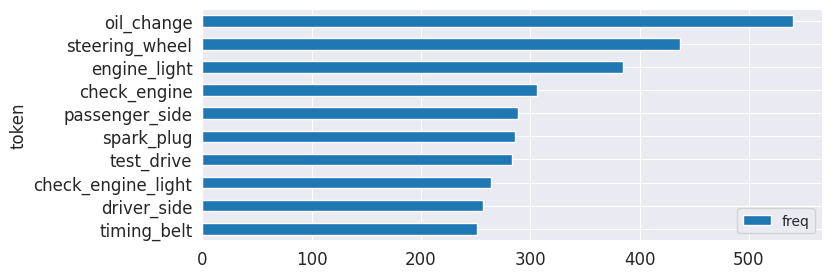

In [ ]:
count_words(df, 'noun_phrases').head(10).plot(kind='barh', figsize=(8,3)).invert_yaxis()

## Persisting the Result


In [ ]:
df[nlp_columns] = df[nlp_columns].applymap(lambda items: ' '.join(items))

con = sqlite3.connect(db_name)
df.to_sql("posts_nlp", con, index=False, if_exists="replace")
con.close()

20000